#This is the parsing part for acquiring raw reviews data on App Store

In [1]:
!pip install requests
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# parameters
app_id = "389801252"  # Instagram
country = "in"
page = 2

In [3]:
url = f"https://itunes.apple.com/{country}/rss/customerreviews/page={page}/id={app_id}/sortby=mostrecent/json"

print(url)

https://itunes.apple.com/in/rss/customerreviews/page=2/id=389801252/sortby=mostrecent/json


In [4]:
response=requests.get(url)
print(response.status_code)

200


In [5]:
# check data structure

data = response.json()

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['feed'])


In [6]:
print(data['feed'].keys())


dict_keys(['author', 'entry', 'updated', 'rights', 'title', 'icon', 'link', 'id'])


In [7]:

print(data['feed']['entry'])
    

[{'author': {'uri': {'label': 'https://itunes.apple.com/in/reviews/id1943674598'}, 'name': {'label': 'Insta user1111'}, 'label': ''}, 'updated': {'label': '2026-07-11T06:19:51-07:00'}, 'im:rating': {'label': '1'}, 'im:version': {'label': '437.2.0'}, 'id': {'label': '14290115875'}, 'title': {'label': 'Bsdk'}, 'content': {'label': 'Bsdk insta story me add firend ka icon de rhe or bo hide karne ke baad bhi aa ja rhe', 'attributes': {'type': 'text'}}, 'link': {'attributes': {'rel': 'related', 'href': 'https://itunes.apple.com/in/review?id=389801252&type=Purple%20Software'}}, 'im:voteSum': {'label': '0'}, 'im:contentType': {'attributes': {'term': 'Application', 'label': 'Application'}}, 'im:voteCount': {'label': '0'}}, {'author': {'uri': {'label': 'https://itunes.apple.com/in/reviews/id1233967501'}, 'name': {'label': 'Saif Mirkar'}, 'label': ''}, 'updated': {'label': '2026-07-11T06:07:37-07:00'}, 'im:rating': {'label': '1'}, 'im:version': {'label': '437.2.0'}, 'id': {'label': '14290075119'}

In [8]:
reviews = []

entries = data["feed"]["entry"]

for review in entries:

    reviews.append({
        "review_id": review["id"]["label"],
        "author": review["author"]["name"]["label"],
        "rating": int(review["im:rating"]["label"]),
        "version": review["im:version"]["label"],
        "title": review["title"]["label"],
        "content": review["content"]["label"],
        "date": review["updated"]["label"]
    })

In [9]:
df=pd.DataFrame(reviews)
df.head()


,review_id,author,rating,version,title,content,date
0,14290115875,Insta user1111,1,437.2.0,Bsdk,Bsdk insta story me add firend ka icon de rhe ...,2026-07-11T06:19:51-07:00
1,14290075119,Saif Mirkar,1,437.2.0,Accounts getting suspended,"We were paying 3,00,000/- INR to insta on mont...",2026-07-11T06:07:37-07:00
2,14290029816,SumitJain3,5,437.2.0,Har Har Mahadev,Feel Good Printing Experience ….,2026-07-11T05:53:43-07:00
3,14289830843,sultan mamud,5,437.2.0,sultan__official__0.3,"Dear Instagram Team, my account (sultan__offic...",2026-07-11T04:49:24-07:00
4,14289791154,Thankyou133,5,437.2.0,Thankyou,I am truly grateful to instagram for showing m...,2026-07-11T04:35:36-07:00


In [10]:
df.shape

df.info()

df["rating"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  50 non-null     object
 1   author     50 non-null     object
 2   rating     50 non-null     int64 
 3   version    50 non-null     object
 4   title      50 non-null     object
 5   content    50 non-null     object
 6   date       50 non-null     object
dtypes: int64(1), object(6)
memory usage: 2.9+ KB


rating
5    30
1    16
4     2
3     1
2     1
Name: count, dtype: int64

In [11]:
# Wrap web-scraping logic into a function

def get_reviews(app_id, country, page=1):

    url = f"https://itunes.apple.com/{country}/rss/customerreviews/page={page}/id={app_id}/sortby=mostrecent/json"

    response = requests.get(url)

    data = response.json()

    reviews = []

    entries = data["feed"]["entry"][1:]

    for review in entries:

        reviews.append({
            "review_id": review["id"]["label"],
            "author": review["author"]["name"]["label"],
            "rating": int(review["im:rating"]["label"]),
            "version": review["im:version"]["label"],
            "title": review["title"]["label"],
            "content": review["content"]["label"],
            "date": review["updated"]["label"]
        })

    return pd.DataFrame(reviews)

In [12]:

def get_reviews(app_id, country, page=1):

    url = f"https://itunes.apple.com/{country}/rss/customerreviews/page={page}/id={app_id}/sortby=mostrecent/json"

    response = requests.get(url)

    data = response.json()

    entries = data["feed"].get("entry", [])

    if isinstance(entries, dict):
        entries = [entries]

    if len(entries) > 1:
        entries = entries[1:]

    reviews = []

    for review in entries:
        reviews.append({
            "review_id": review["id"]["label"],
            "author": review["author"]["name"]["label"],
            "rating": int(review["im:rating"]["label"]),
            "version": review["im:version"]["label"],
            "title": review["title"]["label"],
            "content": review["content"]["label"],
            "date": review["updated"]["label"]
        })

    return pd.DataFrame(reviews)

In [13]:

#Testing first country,first page
df = get_reviews(
    app_id=6448311069,
    country="us",
    page=1
)

df.head()

,review_id,author,rating,version,title,content,date
0,14294266167,Vayadagoat,5,1.2026.183,I like it but don’t at the same time,I’m Vaya and I like it how I can make ai image...,2026-07-12T07:10:14-07:00
1,14294259502,onanramirez,5,1.2026.183,No tiene comparación,Si la usas adecuadamente tendrás un consejero ...,2026-07-12T07:08:17-07:00
2,14294249378,New age q,5,1.2026.183,Simply the best,Simply my best friend,2026-07-12T07:05:22-07:00
3,14294245488,LifeofKwam,5,1.2026.183,My Bestfriend,I love it’s like my right hand man,2026-07-12T07:04:16-07:00
4,14294231760,جيمناي افضل تطبيق,1,1.2026.183,اسوا تطبيق,التطبيق سيى جدددددددداً مانصح فيه جيماني احسن ...,2026-07-12T07:00:20-07:00


In [14]:

apps = {
    "YouTube":544007664,
    "Monopoly GO":1621328561,
    "Candy Crush":553834731,
    "ChatGPT":6448311069,
    "Spotify":324684580
}

countries = ["us", "gb", "au", "ca", "in"]

final_df = []

for app_name, app_id in apps.items():

    for country in countries:

        for page in range(1,10):
        
            print(f"{app_name} | {country} | Page {page}") #check the error
           
            df = get_reviews(
                app_id=app_id,
                country=country,
                page=page
            )
            
            if len(df) == 0:
                continue

            df["app_name"] = app_name
            df['app_id']=app_id
            df["country_name"] = country
            df['review_date']=df['date']
            region_map = {
                          "us": "North America",
                          "ca": "North America",
                          "in": "Asia Pacific",
                          "au": "Asia Pacific",
                          "gb": "Europe"
                          }

            df["region"] = df["country_name"].map(region_map)
            
            final_df.append(df)

YouTube | us | Page 1
YouTube | us | Page 2
YouTube | us | Page 3
YouTube | us | Page 4
YouTube | us | Page 5
YouTube | us | Page 6
YouTube | us | Page 7
YouTube | us | Page 8
YouTube | us | Page 9
YouTube | gb | Page 1
YouTube | gb | Page 2
YouTube | gb | Page 3
YouTube | gb | Page 4
YouTube | gb | Page 5
YouTube | gb | Page 6
YouTube | gb | Page 7
YouTube | gb | Page 8
YouTube | gb | Page 9
YouTube | au | Page 1
YouTube | au | Page 2
YouTube | au | Page 3
YouTube | au | Page 4
YouTube | au | Page 5
YouTube | au | Page 6
YouTube | au | Page 7
YouTube | au | Page 8
YouTube | au | Page 9
YouTube | ca | Page 1
YouTube | ca | Page 2
YouTube | ca | Page 3
YouTube | ca | Page 4
YouTube | ca | Page 5
YouTube | ca | Page 6
YouTube | ca | Page 7
YouTube | ca | Page 8
YouTube | ca | Page 9
YouTube | in | Page 1
YouTube | in | Page 2
YouTube | in | Page 3
YouTube | in | Page 4
YouTube | in | Page 5
YouTube | in | Page 6
YouTube | in | Page 7
YouTube | in | Page 8
YouTube | in | Page 9
Monopoly G

In [15]:
all_reviews = pd.concat(final_df, ignore_index=True)
all_reviews = all_reviews.drop(columns=["date"])

app_category_map={ 'ChatGPT':'AI Assistant',
                   'YouTube':'Video',
                   'Candy Crush':'Gaming',
                   'Spotify':'Gaming',
                   'Monopoly GO':'Gaming'
                 }
all_reviews['app_category']=all_reviews['app_name'].map(app_category_map)
print(all_reviews.shape)

all_reviews.to_csv(
    "Original_Extract_Records_1.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Originally Extracted Records snapshot saved successfully.")


(10931, 12)
Originally Extracted Records snapshot saved successfully.


In [16]:
all_reviews['app_name'].value_counts()

app_name
YouTube        2205
Candy Crush    2205
ChatGPT        2205
Spotify        2205
Monopoly GO    2111
Name: count, dtype: int64

In [17]:
raw_reviews=all_reviews.copy()
raw_reviews.head()

,review_id,author,rating,version,title,content,app_name,app_id,country_name,review_date,region,app_category
0,14294268187,Vero Ba,5,21.26.4,Práctico y gratis,Me gusta que tengo libertad de saviger yve ase...,YouTube,544007664,us,2026-07-12T07:10:49-07:00,North America,Video
1,14294252191,_Jimmer,1,21.26.4,Can’t open app,App opens then immediately closes,YouTube,544007664,us,2026-07-12T07:06:12-07:00,North America,Video
2,14294252069,Emma_ishere,5,21.26.4,I thought if something very cool!,So your know when we find friends on YouTube r...,YouTube,544007664,us,2026-07-12T07:06:10-07:00,North America,Video
3,14294242791,DaHolyJuan,2,21.26.4,App keeps messing up,App keeps messing up and not opening on iOS. H...,YouTube,544007664,us,2026-07-12T07:03:32-07:00,North America,Video
4,14294212596,ladeeduh,1,21.26.4,Some features should be opt-in instead of opt-out,One might think the auto-dubbing feature is “a...,YouTube,544007664,us,2026-07-12T06:54:42-07:00,North America,Video


In [19]:
#Language Check
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def detect_language(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

raw_reviews['review_language'] = (
    raw_reviews['content']
    .apply(detect_language)
)


In [20]:
lang_counts = raw_reviews['review_language'].value_counts()

top5 = lang_counts.head(5)

other = lang_counts.iloc[5:].sum()

lang_summary = pd.concat([
    top5,
    pd.Series({'Other': other})
])

In [21]:
lang_counts = raw_reviews['review_language'].value_counts()

top5 = lang_counts.head(5)

other = lang_counts.iloc[5:].sum()

lang_summary = pd.concat([
    top5,
    pd.Series({'Other': other})
])

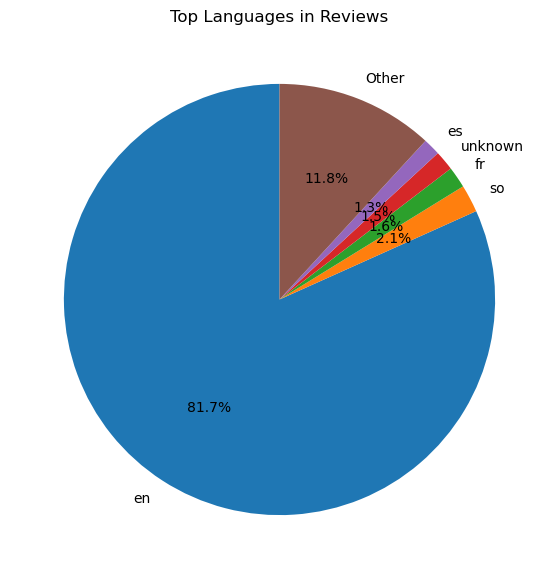

In [22]:
plt.figure(figsize=(8,7))

plt.pie(
    lang_summary,
    labels=lang_summary.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top Languages in Reviews')
plt.show()

In [23]:
raw_reviews.head()

,review_id,author,rating,version,title,content,app_name,app_id,country_name,review_date,region,app_category,review_language
0,14294268187,Vero Ba,5,21.26.4,Práctico y gratis,Me gusta que tengo libertad de saviger yve ase...,YouTube,544007664,us,2026-07-12T07:10:49-07:00,North America,Video,es
1,14294252191,_Jimmer,1,21.26.4,Can’t open app,App opens then immediately closes,YouTube,544007664,us,2026-07-12T07:06:12-07:00,North America,Video,en
2,14294252069,Emma_ishere,5,21.26.4,I thought if something very cool!,So your know when we find friends on YouTube r...,YouTube,544007664,us,2026-07-12T07:06:10-07:00,North America,Video,en
3,14294242791,DaHolyJuan,2,21.26.4,App keeps messing up,App keeps messing up and not opening on iOS. H...,YouTube,544007664,us,2026-07-12T07:03:32-07:00,North America,Video,en
4,14294212596,ladeeduh,1,21.26.4,Some features should be opt-in instead of opt-out,One might think the auto-dubbing feature is “a...,YouTube,544007664,us,2026-07-12T06:54:42-07:00,North America,Video,en


In [26]:
raw_reviews['app_name'].value_counts()

app_name
YouTube        2205
Candy Crush    2205
ChatGPT        2205
Spotify        2205
Monopoly GO    2111
Name: count, dtype: int64

In [27]:
raw_reviews['country_name'].value_counts()

country_name
us    2205
gb    2205
au    2205
ca    2205
in    2111
Name: count, dtype: int64

In [28]:
raw_reviews.dtypes

review_id          object
author             object
rating              int64
version            object
title              object
content            object
app_name           object
app_id              int64
country_name       object
review_date        object
region             object
app_category       object
review_language    object
dtype: object

In [29]:
pd.crosstab(
    raw_reviews['app_name'],
    raw_reviews['country_name']
)

country_name,au,ca,gb,in,us
app_name,,,,,
Candy Crush,441,441,441,441,441
ChatGPT,441,441,441,441,441
Monopoly GO,441,441,441,347,441
Spotify,441,441,441,441,441
YouTube,441,441,441,441,441


#This is the part for Exploratory Data Analysis and Data preprocessing

In [30]:
# Missing Values Check(1)
raw_reviews.isna().sum()


review_id          0
author             0
rating             0
version            0
title              0
content            0
app_name           0
app_id             0
country_name       0
review_date        0
region             0
app_category       0
review_language    0
dtype: int64

In [31]:
#Missing Value Check(2)
#For special NAs characters

placeholders = [
    'unknown',
    'n/a',
    'na',
    'not available',
    'none',
    'null',
    '-'
]

for col in ['author', 'version', 'title', 'content', 'review_date', 'country_name']:
    count = (
        raw_reviews[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(placeholders)
        .sum()
    )
    print(col, count)

author 0
version 0
title 3
content 1
review_date 0
country_name 0


In [32]:
raw_reviews.loc[
    raw_reviews["content"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(placeholders),
    ["review_id", "title", "content", "app_name", "country_name"]
]

,review_id,title,content,app_name,country_name
8625,14274280739,Na,Na,ChatGPT,in


In [33]:
raw_reviews['review_id'].duplicated().sum()

np.int64(0)

In [34]:
raw_reviews["duplicate_flag"] = raw_reviews["review_id"].duplicated()

In [77]:
import re

def clean_text(text):

    # Convert input to string format
    text = str(text)

    # Convert all characters to lowercase
    text = text.lower()

    # Remove URLs (e.g., https://..., www....)
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove emojis and non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)

    # Remove leading and trailing spaces,
    return text.strip()

In [80]:

# Record Remove Reason
raw_reviews["record_remove_reason"] = None

#Reason: Missing Review Content
missing_content = (
    raw_reviews["content"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["", "na", "n/a", "unknown"])
)

raw_reviews.loc[
    missing_content & raw_reviews["record_remove_reason"].isna(),
    "record_remove_reason"
] = "Missing Review Content"

#Reason: Duplicated Records
duplicated_records=(raw_reviews['review_id'].duplicated())

raw_reviews.loc[
    duplicated_records & raw_reviews["record_remove_reason"].isna(),
    'record_remove_reason'
    ]='Duplicated Records'

#Reason: Non-English Review Content
non_English_content=(raw_reviews['review_language']!='en'
)

raw_reviews.loc[
    non_English_content & raw_reviews["record_remove_reason"].isna(),
    'record_remove_reason'
    ]='Non-English Review Content'

# Reason: Empty after the review content get cleaned
raw_reviews["clean_content"] = (
    raw_reviews["content"]
    .apply(clean_text)
)

empty_after_cleaning = (
    raw_reviews["clean_content"]
    .str.len()==0
    
)

raw_reviews.loc[
    empty_after_cleaning &
    raw_reviews["record_remove_reason"].isna(),
    "record_delete_reason"
] = "Empty Content After Cleaning"

#Drop redundant columns
raw_reviews.drop(
    columns=[
        "record_delete_reason",
        "clean_content"
    ],
    inplace=True
)

In [81]:
raw_reviews.head()

,review_id,author,rating,version,title,content,app_name,app_id,country_name,review_date,region,app_category,review_language,duplicate_flag,record_remove_reason
0,14294268187,Vero Ba,5,21.26.4,Práctico y gratis,Me gusta que tengo libertad de saviger yve ase...,YouTube,544007664,us,2026-07-12T07:10:49-07:00,North America,Video,es,False,Non-English Review Content
1,14294252191,_Jimmer,1,21.26.4,Can’t open app,App opens then immediately closes,YouTube,544007664,us,2026-07-12T07:06:12-07:00,North America,Video,en,False,None
2,14294252069,Emma_ishere,5,21.26.4,I thought if something very cool!,So your know when we find friends on YouTube r...,YouTube,544007664,us,2026-07-12T07:06:10-07:00,North America,Video,en,False,None
3,14294242791,DaHolyJuan,2,21.26.4,App keeps messing up,App keeps messing up and not opening on iOS. H...,YouTube,544007664,us,2026-07-12T07:03:32-07:00,North America,Video,en,False,None
4,14294212596,ladeeduh,1,21.26.4,Some features should be opt-in instead of opt-out,One might think the auto-dubbing feature is “a...,YouTube,544007664,us,2026-07-12T06:54:42-07:00,North America,Video,en,False,None


In [82]:
raw_reviews["record_remove_reason"].value_counts(dropna=False)

record_remove_reason
None                          8933
Non-English Review Content    1997
Missing Review Content           1
Name: count, dtype: int64

In [83]:
raw_reviews.to_csv(
    "raw_reviews_3.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Raw Reviews snapshot saved successfully.")

Raw Reviews snapshot saved successfully.


In [84]:
cleaned_reviews=raw_reviews.copy()

In [85]:
cleaned_reviews = cleaned_reviews.drop_duplicates(
    subset='review_id'
)

In [86]:
# Date datatype Check
cleaned_reviews['review_date'].dtype

dtype('O')

In [87]:
cleaned_reviews['date_transformed'] = pd.to_datetime(raw_reviews['review_date'])

In [88]:
cleaned_reviews['date_transformed'].dtype

datetime64[ns, UTC-07:00]

In [89]:
#Time Window
cleaned_reviews['date_transformed'].min()

Timestamp('2023-04-11 11:21:47-0700', tz='UTC-07:00')

In [90]:
cleaned_reviews['date_transformed'].max()

Timestamp('2026-07-12 07:10:49-0700', tz='UTC-07:00')

In [91]:
cleaned_reviews['rating'].value_counts().sort_index()

rating
1    2977
2     691
3     836
4     793
5    5634
Name: count, dtype: int64

In [92]:
cleaned_reviews=cleaned_reviews[cleaned_reviews['record_remove_reason'].isna().copy()]

In [93]:
cleaned_reviews["content_cleaned"] = (
    raw_reviews["content"]
    .apply(clean_text)
)

In [51]:
print(cleaned_reviews.columns.tolist())

['review_id', 'author', 'rating', 'version', 'title', 'content', 'app_name', 'app_id', 'country_name', 'region', 'app_category', 'review_language', 'duplicate_flag', 'record_remove_reason', 'date_transformed', 'content_cleaned']


In [94]:
cleaned_reviews.count()

review_id               8933
author                  8933
rating                  8933
version                 8933
title                   8933
content                 8933
app_name                8933
app_id                  8933
country_name            8933
review_date             8933
region                  8933
app_category            8933
review_language         8933
duplicate_flag          8933
record_remove_reason       0
date_transformed        8933
content_cleaned         8933
dtype: int64

In [70]:
cleaned_reviews.to_csv(
    "cleaned_reviews_2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Cleaned Reviews snapshot saved successfully.")

Cleaned Reviews snapshot saved successfully.


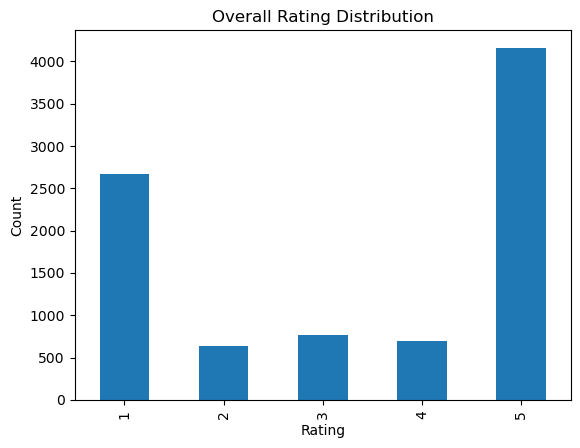

In [71]:
import matplotlib.pyplot as plt

cleaned_reviews['rating'].value_counts()\
.sort_index()\
.plot(kind='bar')

plt.title('Overall Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

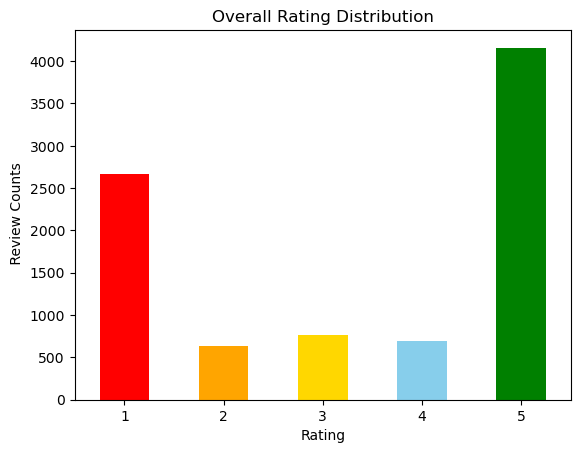

In [72]:
import matplotlib.pyplot as plt

rating_counts = (
    cleaned_reviews['rating']
    .value_counts()
    .sort_index()
)

rating_counts.plot(
    kind='bar',
    color=['red', 'orange', 'gold', 'skyblue', 'green']
)

plt.title('Overall Rating Distribution')
plt.xlabel('Rating')
plt.ylabel(' Review Counts')

# label transform
plt.xticks(rotation=0)

plt.show()

In [73]:
pd.crosstab(
    cleaned_reviews['app_name'],
    cleaned_reviews['rating'],
    normalize='index'
).round(3) * 100

rating,1,2,3,4,5
app_name,,,,,
Candy Crush,45.3,11.2,11.6,6.9,25.1
ChatGPT,17.0,3.1,4.5,5.4,70.0
Monopoly GO,27.2,6.4,7.4,8.9,50.2
Spotify,18.8,5.2,8.6,10.8,56.6
YouTube,39.1,9.3,10.2,6.7,34.7


In [74]:
rating_pct = (
    pd.crosstab(
        cleaned_reviews['app_name'],
        cleaned_reviews['rating'],
        normalize='index'
    )
    .mul(100)
    .round(1)
)

rating_pct = rating_pct.astype(str) + '%'

rating_pct

rating,1,2,3,4,5
app_name,,,,,
Candy Crush,45.3%,11.2%,11.6%,6.9%,25.1%
ChatGPT,17.0%,3.1%,4.5%,5.4%,70.0%
Monopoly GO,27.2%,6.4%,7.4%,8.9%,50.2%
Spotify,18.8%,5.2%,8.6%,10.8%,56.6%
YouTube,39.1%,9.3%,10.2%,6.7%,34.7%


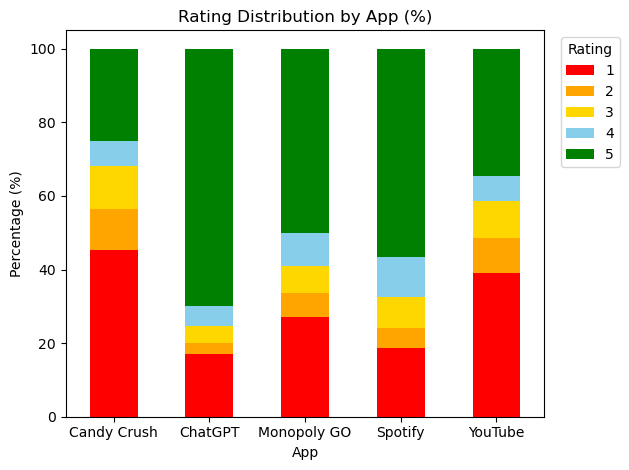

In [75]:
rating_pct = (
    pd.crosstab(
        cleaned_reviews['app_name'],
        cleaned_reviews['rating'],
        normalize='index'
    )
    * 100
)

ax = rating_pct.plot(
    kind='bar',
    color=['red', 'orange', 'gold', 'skyblue', 'green'],
    stacked=True,
    
)

plt.title('Rating Distribution by App (%)')
plt.xlabel('App')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=0)

plt.legend(
    title='Rating',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [76]:
rating_pct = (
    pd.crosstab(
        cleaned_reviews['country_name'],
        cleaned_reviews['rating'],
        normalize='index'
    )
    .mul(100)
    .round(1)
)

rating_pct = rating_pct.astype(str) + '%'

rating_pct

rating,1,2,3,4,5
country_name,,,,,
au,26.1%,6.4%,9.2%,8.4%,49.9%
ca,34.3%,8.9%,8.6%,8.2%,40.0%
gb,27.7%,6.5%,8.8%,8.8%,48.1%
in,34.3%,7.0%,6.6%,6.3%,45.8%
us,28.1%,6.9%,9.3%,6.8%,48.9%


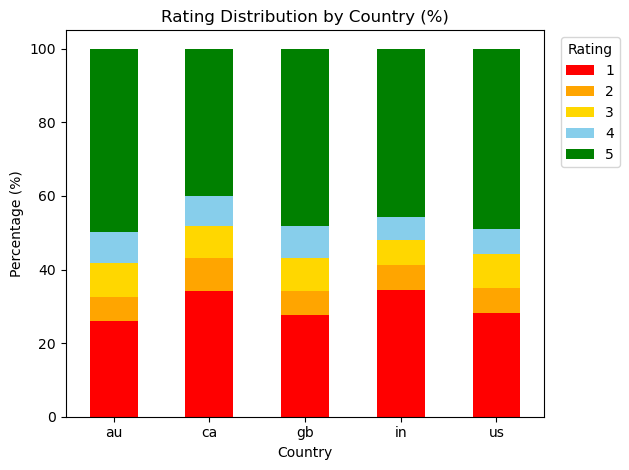

In [77]:
rating_pct = (
    pd.crosstab(
        cleaned_reviews['country_name'],
        cleaned_reviews['rating'],
        normalize='index'
    )
    * 100
)

ax = rating_pct.plot(
    kind='bar',
    color=['red', 'orange', 'gold', 'skyblue', 'green'],
    stacked=True,
    
)

plt.title('Rating Distribution by Country (%)')
plt.xlabel('Country')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=0)

plt.legend(
    title='Rating',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

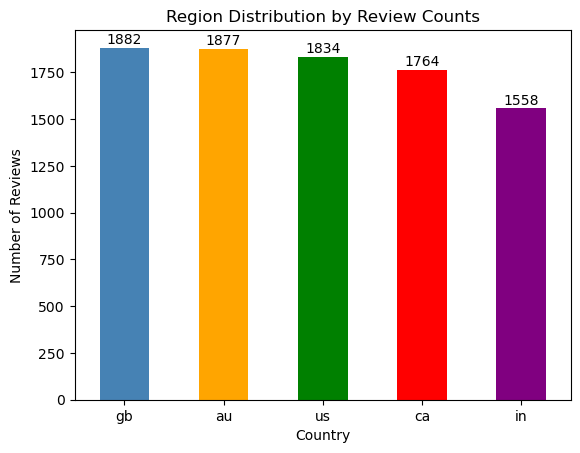

In [78]:
import matplotlib.pyplot as plt

country_counts = cleaned_reviews['country_name'].value_counts()

country_counts.plot(
    kind='bar',
    color=['steelblue', 'orange', 'green', 'red', 'purple']
)

plt.title('Region Distribution by Review Counts')
plt.xlabel('Country')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

# count label
for i, v in enumerate(country_counts):
    plt.text(i, v + 20, str(v), ha='center')

plt.show()

In [79]:
cleaned_reviews['word_count'] = (
    all_reviews['content']
    .str.split()
    .str.len()
)

In [80]:
cleaned_reviews['word_count'].describe()

count    8915.000000
mean       28.513741
std        36.653810
min         1.000000
25%         8.000000
50%        17.000000
75%        36.000000
max       830.000000
Name: word_count, dtype: float64

In [82]:
cleaned_reviews.groupby('app_name')['version'].nunique()

app_name
Candy Crush     67
ChatGPT          8
Monopoly GO    107
Spotify          5
YouTube         12
Name: version, dtype: int64

# This is the part for Data Schema Design and Data Ingestion

In [53]:

raw_reviews["review_id"].duplicated().sum()

np.int64(0)

In [96]:
#create tables for the schema
app_mysql = (
    raw_reviews[
        ["app_id", "app_name", "app_category"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


country_mysql = (
    raw_reviews[
        ["country_name", "region"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

country_mysql.insert(
    0,
    "country_id",
    range(1, len(country_mysql) + 1)
)

raw_reviews_mysql = raw_reviews.merge(
    country_mysql,
    on=["country_name", "region"],
    how="left"
)

raw_reviews_mysql = raw_reviews_mysql[
    [
        "review_id",
        "app_id",
        "country_id",
        "author",
        "rating",
        "version",
        "title",
        "content",
        "review_date",
        "review_language",
        "duplicate_flag",
        "record_remove_reason"
    ]
].copy()

raw_reviews_mysql.insert(
    0,
    "raw_review_pk",
    range(1, len(raw_reviews_mysql) + 1)
)


cleaned_reviews_mysql = cleaned_reviews[
    [
        "review_id",
        "content_cleaned",
        "date_transformed"
    ]
].copy()

cleaned_reviews_mysql.insert(
    0,
    "clean_review_pk",
    range(1, len(cleaned_reviews_mysql) + 1)
)


cleaned_reviews_mysql = cleaned_reviews_mysql.merge(
    raw_reviews_mysql[
        ["review_id", "raw_review_pk"]
    ],
    on="review_id",
    how="left"
)

cleaned_reviews_mysql = cleaned_reviews_mysql[
    [
        "clean_review_pk",
        "raw_review_pk",
        "content_cleaned",
        "date_transformed"
    ]
]

In [97]:
cleaned_reviews_mysql.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8933 entries, 0 to 8932
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype                    
---  ------            --------------  -----                    
 0   clean_review_pk   8933 non-null   int64                    
 1   raw_review_pk     8933 non-null   int64                    
 2   content_cleaned   8933 non-null   object                   
 3   date_transformed  8933 non-null   datetime64[ns, UTC-07:00]
dtypes: datetime64[ns, UTC-07:00](1), int64(2), object(1)
memory usage: 279.3+ KB


In [56]:
cleaned_reviews_mysql["clean_review_pk"].is_unique

True

In [57]:
cleaned_reviews_mysql["raw_review_pk"].isin(
    raw_reviews_mysql["raw_review_pk"]
).all()

np.True_

In [58]:
print("App:", app_mysql.shape)
print("Country:", country_mysql.shape)
print("Raw:", raw_reviews_mysql.shape)
print("Cleaned:", cleaned_reviews_mysql.shape)

print("App PK:", app_mysql["app_id"].is_unique)
print("Country PK:", country_mysql["country_id"].is_unique)
print("Raw PK:", raw_reviews_mysql["raw_review_pk"].is_unique)
print("Clean PK:", cleaned_reviews_mysql["clean_review_pk"].is_unique)

App: (5, 3)
Country: (5, 3)
Raw: (10931, 13)
Cleaned: (8933, 4)
App PK: True
Country PK: True
Raw PK: True
Clean PK: True


In [59]:
raw_reviews_mysql["country_id"].isin(
    country_mysql["country_id"]
).all()

np.True_

In [60]:
raw_reviews_mysql["app_id"].isin(
    app_mysql["app_id"]
).all()

np.True_

In [61]:
cleaned_reviews_mysql["raw_review_pk"].isin(
    raw_reviews_mysql["raw_review_pk"]
).all()

np.True_

In [62]:
cleaned_reviews_mysql["raw_review_pk"].duplicated().sum()

np.int64(0)

In [99]:
# Snapshot csv
app_mysql.to_csv("App.csv", index=False, encoding="utf-8-sig")

country_mysql.to_csv("Country.csv", index=False, encoding="utf-8-sig")

raw_reviews_mysql.to_csv("Raw_Reviews_final.csv", index=False, encoding="utf-8-sig")

cleaned_reviews_mysql.to_csv("Cleaned_Reviews_final.csv", index=False, encoding="utf-8-sig")

In [98]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Fan65101265",          
    database="appstore_reviews"
)

cursor = conn.cursor()

print("Connected successfully!")

Connected successfully!


In [99]:
# Insert App table

sql = """
INSERT INTO App (
    app_id,
    app_name,
    app_category
)
VALUES (%s, %s, %s)
"""

inserted = 0
duplicates = 0
errors = 0

for row in app_mysql.itertuples(index=False):

    try:
        cursor.execute(sql, tuple(row))
        inserted += 1

    except mysql.connector.IntegrityError:
        # Primary key already exists
        duplicates += 1

    except Exception as e:
        print(e)
        errors += 1

conn.commit()

print(f"Inserted: {inserted}")
print(f"Duplicates: {duplicates}")
print(f"Errors: {errors}")

Inserted: 0
Duplicates: 5
Errors: 0


In [100]:
# Insert Country table

sql = """
INSERT INTO Country (
    country_id,
    country_name,
    region
)
VALUES (%s, %s, %s)
"""

inserted = 0
duplicates = 0
errors = 0

for row in country_mysql.itertuples(index=False):

    try:
        cursor.execute(sql, tuple(row))
        inserted += 1

    except mysql.connector.IntegrityError:
        duplicates += 1

    except Exception as e:
        print(e)
        errors += 1

conn.commit()

print(f"Inserted: {inserted}")
print(f"Duplicates: {duplicates}")
print(f"Errors: {errors}")

Inserted: 0
Duplicates: 5
Errors: 0


In [101]:
sql = """
INSERT INTO raw_reviews (
    raw_review_pk,
    review_id,
    app_id,
    country_id,
    author,
    rating,
    version,
    title,
    content,
    review_date,
    review_language,
    duplicate_flag,
    record_remove_reason
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

inserted = 0
duplicates = 0
errors = 0

for row in raw_reviews_mysql.itertuples(index=False):

    try:
        cursor.execute(sql, tuple(row))
        inserted += 1

    except mysql.connector.IntegrityError:
        duplicates += 1

    except Exception as e:
        print(e)
        errors += 1

conn.commit()

print(f"Inserted: {inserted}")
print(f"Duplicates: {duplicates}")
print(f"Errors: {errors}")

Inserted: 0
Duplicates: 10931
Errors: 0


In [102]:
sql = """
INSERT INTO cleaned_reviews (
    clean_review_pk,
    raw_review_pk,
    content_cleaned,
    date_transformed
)
VALUES (%s, %s, %s, %s)
"""

inserted = 0
duplicates = 0
errors = 0

for row in cleaned_reviews_mysql.itertuples(index=False):

    try:
        cursor.execute(sql, tuple(row))
        inserted += 1

    except mysql.connector.IntegrityError:
        duplicates += 1

    except Exception as e:
        print(e)
        errors += 1

conn.commit()

print(f"Inserted: {inserted}")
print(f"Duplicates: {duplicates}")
print(f"Errors: {errors}")

Inserted: 0
Duplicates: 8933
Errors: 0


In [68]:
len(raw_reviews_mysql)

10931

In [69]:
print("Raw:", len(raw_reviews_mysql))
print("Cleaned:", len(cleaned_reviews_mysql))

print("Raw review_id duplicates:",
      raw_reviews_mysql["review_id"].duplicated().sum())

print("Cleaned review_id duplicates:",
      cleaned_reviews["review_id"].duplicated().sum())

Raw: 10931
Cleaned: 8933
Raw review_id duplicates: 0
Cleaned review_id duplicates: 0


In [103]:
raw_reviews_mysql["record_remove_reason"].value_counts(dropna=False)

record_remove_reason
None                          8933
Non-English Review Content    1997
Missing Review Content           1
Name: count, dtype: int64

In [104]:
raw_reviews_mysql[
    raw_reviews_mysql["review_id"] == "14274280739"
]

,raw_review_pk,review_id,app_id,country_id,author,rating,version,title,content,review_date,review_language,duplicate_flag,record_remove_reason
8625,8626,14274280739,6448311069,5,s.wasim,5,1.2026.181,Na,Na,2026-07-07T07:43:32-07:00,vi,False,Missing Review Content
